In [1]:
import struct
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open('./sms.txt') as f:
    lines = f.readlines()

lines

['//SCKL1583 0B05041583000000030103013000480E01FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFBFFF9FFFFF3FFC71FFFFFFDFFFEFBFFDED0F32\n',
 '//SCKL1583 0B050415830000000301030273DFFCC18FF8EDB7BDE1DFFB6FB7FB71B7BAEFDFFB6DB7FB7B8F12718FFCF30FF8E3BFFFFFFFFFFFFFFFFF1FFFFFFFFFFFFFFFFF\n',
 '//SCKL1583 0B0504158300000003010303FFFFFFFC0FFFFC0FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF00']

In [3]:
messages = list(map(lambda x: x.split(' ')[1][24:], lines))
messages

['3000480E01FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFBFFF9FFFFF3FFC71FFFFFFDFFFEFBFFDED0F32\n',
 '73DFFCC18FF8EDB7BDE1DFFB6FB7FB71B7BAEFDFFB6DB7FB7B8F12718FFCF30FF8E3BFFFFFFFFFFFFFFFFF1FFFFFFFFFFFFFFFFF\n',
 'FFFFFFFC0FFFFC0FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF00']

In [4]:
complete_payload = ''.join(messages)

In [5]:
data = bytes.fromhex(complete_payload)
data = data[1:]

In [6]:
magic_byte, image_width, image_height, color_space = struct.unpack('>BBBB', data[:4])
image_data = data[4:]
assert magic_byte == 0x00, 'Invalid magic byte'
assert color_space == 0x01, 'Invalid color space'
magic_byte, image_width, image_height, color_space

(0, 72, 14, 1)

In [7]:
image_width / 8

9.0

In [8]:
img = np.zeros((image_height, image_width, 1), dtype=np.uint8)

for row in range(image_height):
    for col in range(image_width):
        val = image_data[row * image_width // 8 + col // 8] & (1 << (7 - col % 8))
        img[row, col, 0] = 255 if val != 0 else 0

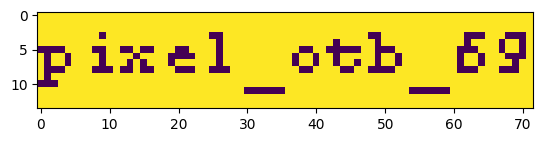

In [9]:
plt.imshow(img, interpolation='nearest')
plt.show()
